In [16]:
import pandas as pd 
from sklearn.preprocessing import RobustScaler
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


In [8]:
df = pd.read_csv("Copia de data_merged.csv")

In [9]:
df.head()

,acousticness,danceability,duration_ms,energy,explicit,instrumentalness,liveness,loudness,popularity,speechiness,...,valence_yr,popularity_yr,mode,key_0_yr,key_1_yr,key_2_yr,key_3_yr,key_4_yr,key_5_yr,key_6_yr
0,0.0131,0.2560,182347,0.895,0,0.000106,0.0821,-4.860,29,0.0707,...,0.583424,35.272231,1,0,0,1,0,0,0,0
1,0.9800,0.2770,206972,0.145,0,0.879000,0.1110,-19.898,0,0.0845,...,0.432251,3.672500,1,1,0,0,0,0,0,0
2,0.7950,0.6850,314667,0.483,0,0.878000,0.1130,-10.202,1,0.0337,...,0.447291,7.707000,1,0,0,0,1,0,0,0
3,0.6560,0.7880,179747,0.808,0,0.000000,0.1540,-6.590,0,0.0395,...,0.447291,7.707000,1,0,0,0,1,0,0,0
4,0.3020,0.0753,498560,0.150,0,0.884000,0.1210,-16.705,0,0.0371,...,0.443625,3.419500,1,1,0,0,0,0,0,0


In [10]:

df_processed = df.copy()

initial_rows = len(df_processed)
df_processed = df_processed.dropna()

df_processed['duration_ms'] = df_processed['duration_ms']/60000



# 1. Variable binaria (popular vs no popular)
# la mediana como punto de corte
popularity_median = df_processed['popularity'].median()
print(f"   - Mediana de popularidad: {popularity_median}")
df_processed['is_popular_binary'] = (df_processed['popularity'] > popularity_median).astype(int)

# 2. Variable multiclase (3 niveles: Baja, Media, Alta)
# Usar terciles para dividir en 3 categorías
terciles = df_processed['popularity'].quantile([0.33, 0.67])
print(f"   - Terciles de popularidad: {terciles.values}")

def categorize_popularity(popularity):
    if popularity <= terciles[0.33]:
        return 0  # Baja
    elif popularity <= terciles[0.67]:
        return 1  # Media
    else:
        return 2  # Alta

df_processed['popularity_multiclass'] = df_processed['popularity'].apply(categorize_popularity)

# 3. Variable multiclase (5 niveles: Muy Baja, Baja, Media, Alta, Muy Alta)
quintiles = df_processed['popularity'].quantile([0.2, 0.4, 0.6, 0.8])
print(f"   - Quintiles de popularidad: {quintiles.values}")

def categorize_popularity_5levels(popularity):
    if popularity <= quintiles[0.2]:
        return 0  # Muy Baja
    elif popularity <= quintiles[0.4]:
        return 1  # Baja
    elif popularity <= quintiles[0.6]:
        return 2  # Media
    elif popularity <= quintiles[0.8]:
        return 3  # Alta
    else:
        return 4  # Muy Alta

df_processed['popularity_5levels'] = df_processed['popularity'].apply(categorize_popularity_5levels)

print("Variable binaria (is_popular_binary):")
print(df_processed['is_popular_binary'].value_counts().sort_index())
print(f"   Proporción: {df_processed['is_popular_binary'].mean():.3f}")

print("\nVariable multiclase 3 niveles (popularity_multiclass):")
multiclass_counts = df_processed['popularity_multiclass'].value_counts().sort_index()
multiclass_labels = ['Baja', 'Media', 'Alta']
for i, (count, label) in enumerate(zip(multiclass_counts, multiclass_labels)):
    print(f"   {i} ({label}): {count} ({count/len(df_processed)*100:.1f}%)")

print("\nVariable multiclase 5 niveles (popularity_5levels):")
fiveclass_counts = df_processed['popularity_5levels'].value_counts().sort_index()
fiveclass_labels = ['Muy Baja', 'Baja', 'Media', 'Alta', 'Muy Alta']
for i, (count, label) in enumerate(zip(fiveclass_counts, fiveclass_labels)):
    print(f"   {i} ({label}): {count} ({count/len(df_processed)*100:.1f}%)")

print(f"\n✅ Preprocesamiento completado")
print(f"📊 Dataset final: {df_processed.shape[0]} filas, {df_processed.shape[1]} columnas")

   - Mediana de popularidad: 26.0
   - Terciles de popularidad: [ 9. 37.]
   - Quintiles de popularidad: [ 0. 17. 32. 46.]
Variable binaria (is_popular_binary):
is_popular_binary
0    88034
1    84196
Name: count, dtype: int64
   Proporción: 0.489

Variable multiclase 3 niveles (popularity_multiclass):
   0 (Baja): 57080 (33.1%)
   1 (Media): 60091 (34.9%)
   2 (Alta): 55059 (32.0%)

Variable multiclase 5 niveles (popularity_5levels):
   0 (Muy Baja): 39729 (23.1%)
   1 (Baja): 29179 (16.9%)
   2 (Media): 34591 (20.1%)
   3 (Alta): 34303 (19.9%)
   4 (Muy Alta): 34428 (20.0%)

✅ Preprocesamiento completado
📊 Dataset final: 172230 filas, 75 columnas


In [11]:
scaler = RobustScaler()
_X = df_processed.copy()
X = _X.drop(columns=['popularity','popularity_multiclass','is_popular_binary','popularity_5levels'])
X = scaler.fit_transform(X)
y_binary = df_processed['is_popular_binary']
y_multiclass_3 = df_processed['popularity_multiclass'] 
y_multiclass_5 = df_processed['popularity_5levels']


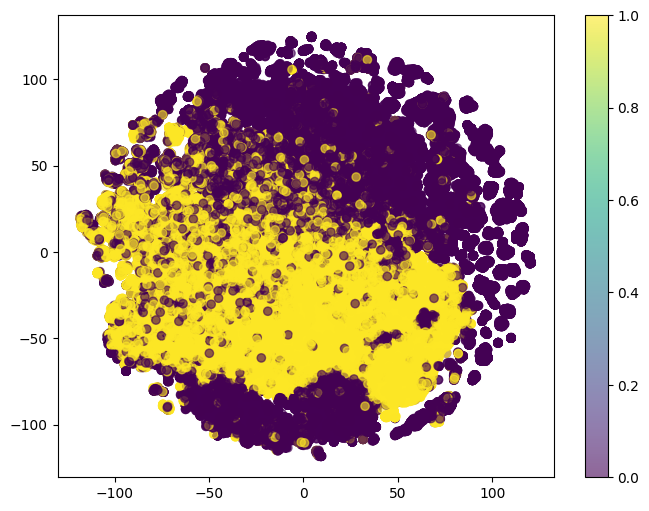

In [12]:

tsne = TSNE(n_components=2,random_state=42)
X_tsne  = tsne.fit_transform(X)
plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:,0],X_tsne[:,1],c=y_binary,cmap='viridis',alpha=0.6)
plt.colorbar()
plt.show()

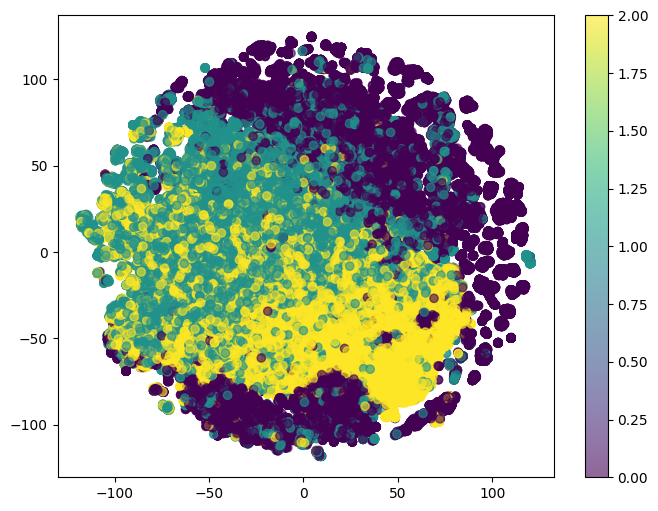

In [13]:
plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:,0],X_tsne[:,1],c=y_multiclass_3,cmap='viridis',alpha=0.6)
plt.colorbar()
plt.show()

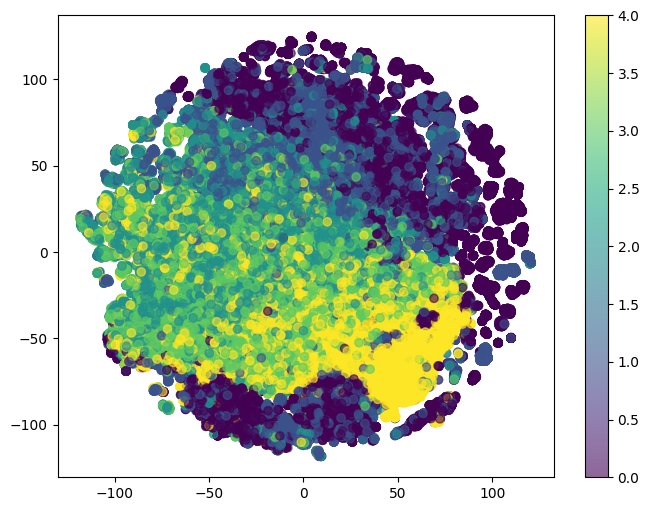

In [14]:
plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:,0],X_tsne[:,1],c=y_multiclass_5,cmap='viridis',alpha=0.6)
plt.colorbar()
plt.show()

In [40]:
pca = PCA(n_components=0.95)
import numpy as np
X_pca=pca.fit(X)
a= np.cumsum(pca.explained_variance_ratio_)
a


array([0.54902365, 0.65144083, 0.70337136, 0.75104265, 0.79306139,
       0.82054392, 0.84656135, 0.86297128, 0.87787632, 0.88935343,
       0.9000299 , 0.90801033, 0.91531961, 0.92237728, 0.92908069,
       0.93543602, 0.94018749, 0.94457519, 0.94826237, 0.95148278])

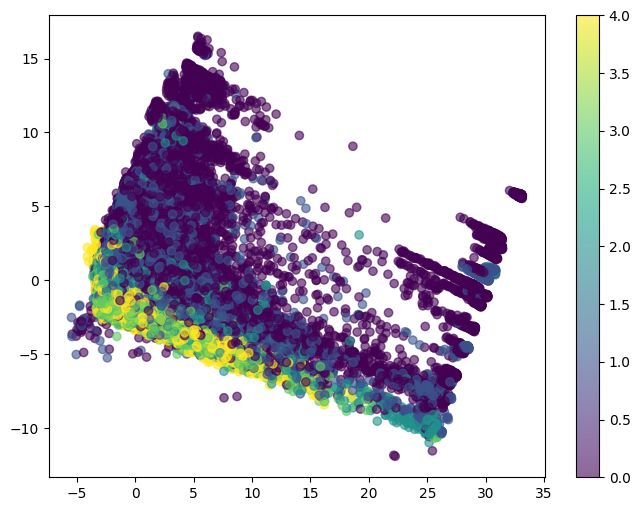

In [28]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0],X_pca[:,1],c=y_multiclass_5,cmap='viridis',alpha=0.6)
plt.colorbar()
plt.show()

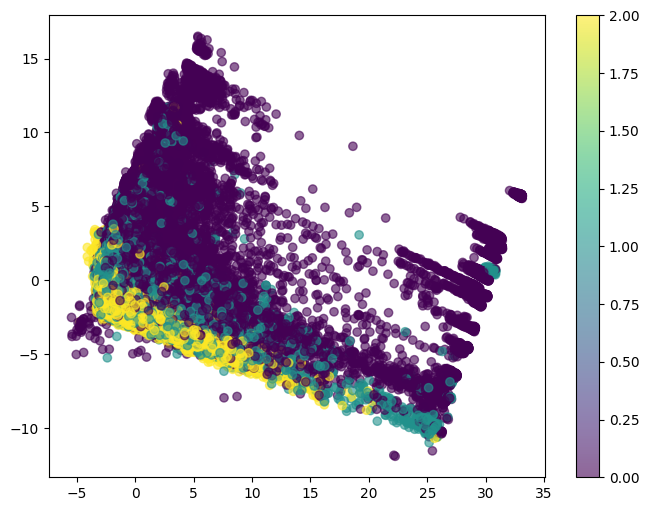

In [29]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0],X_pca[:,1],c=y_multiclass_3,cmap='viridis',alpha=0.6)
plt.colorbar()
plt.show()

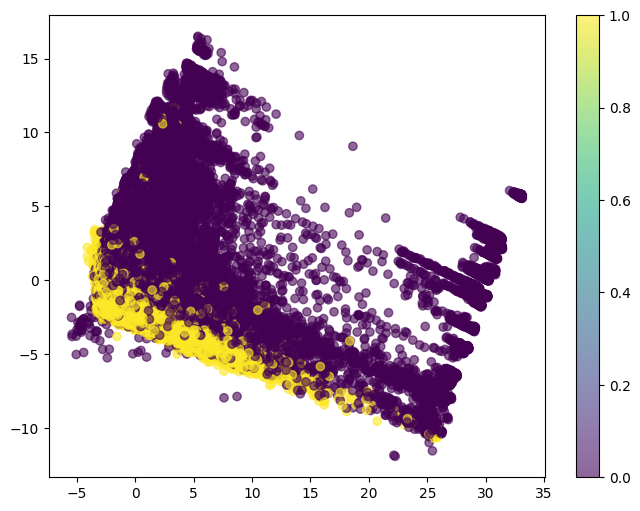

In [30]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0],X_pca[:,1],c=y_binary,cmap='viridis',alpha=0.6)
plt.colorbar()
plt.show()

In [31]:
pca = PCA(n_components=2)
X_pca=pca.fit_transform(X)

tsne = TSNE(n_components=2,random_state=42)
X_tsne  = tsne.fit_transform(X_pca)

KeyboardInterrupt: 

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0],X_pca[:,1],c=y_binary,cmap='viridis',alpha=0.6)
plt.colorbar()
plt.show()

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0],X_pca[:,1],c=y_multiclass_3,cmap='viridis',alpha=0.6)
plt.colorbar()
plt.show()

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0],X_pca[:,1],c=y_multiclass_5,cmap='viridis',alpha=0.6)
plt.colorbar()
plt.show()